In [2]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

sys.path.insert(0, '..')  # dataset.py lives one level up, shared across experiment types
import dataset
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import model as model_module
import numpy as np
import pandas as pd
import torch
import train as train_module
from sklearn.metrics import confusion_matrix

from investalyze.analysis import encodings
from investalyze.ingest import storage

plt.rcParams['figure.dpi'] = 130

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
TICKERS = None  # list[str] of specific tickers, int for a random sample of that many, or None for all
UNIVERSE = None  # name of a universe saved by the ticker selector app (data/universes/<name>.csv); overrides TICKERS when set
EXCLUDE_TICKERS = [
    # 'LITX',
    # 'PCG-PD',
    # 'LIFE',
    # 'AKRE',
    # 'BOBS',
    # 'BKMI',
    # 'QBTZ',
    # 'XWIN',
    # 'SHAZ',
    # 'OPENL',
    # 'HOYY',
    # 'JBS',
    # 'NSIT',
]  # tickers to always leave out, regardless of TICKERS or UNIVERSE

SEED = 0  # used when TICKERS is an int, and when VALID_METHOD is 'random'
WINDOW_LENGTH = 30
STRIDE = 15

VALID_FRAC = 0.3
VALID_METHOD = 'random'  # 'recent' = time-based (no leakage) / 'random' = random per-window
TEST_N = 1  # always recent: the last N windows of each ticker

ENCODER = encodings.zscore  # swap by hand: RebaseTo100 / RebaseTo1 / encodings.zscore / encodings.minmax
# ENCODER = encodings.minmax  # swap by hand: RebaseTo100 / RebaseTo1 / encodings.zscore / encodings.minmax
BATCH_SIZE = 1024 * 16
EPOCHS = 300000000000000
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

HIDDEN = 64
DROPOUT = 0.1
N_BLOCKS = 20  # residual conv blocks (skip connection per block)
KERNEL_START = 3  # kernel size of the stem conv + first residual blocks
KERNEL_END = 9  # kernel size reached by the last residual block (quadratic ramp, odd sizes only)

LR = 1e-3
WEIGHT_DECAY = 0.01  # AdamW L2-ish regularization, applied directly to weights not through the gradient
LR_FACTOR = 0.5  # ReduceLROnPlateau: multiply lr by this on plateau
LR_PATIENCE = 20  # ReduceLROnPlateau: epochs of no valid_loss improvement before reducing lr
LR_METRIC = 'valid'  # 'valid' normally / 'train' when deliberately overfitting to sanity-check capacity

EARLY_STOP_PATIENCE = 100000000  # stop if valid_loss hasn't improved in this many epochs
EVAL_CHECKPOINT = 'valid_loss'  # 'last' / 'train_loss' / 'valid_loss' / 'train_acc' / 'valid_acc'

In [4]:
DATA_ROOT = Path('../../data')

con = storage.connect(DATA_ROOT, read_only=True)
if UNIVERSE is not None:
    tickers = [t for t in dataset.load_universe(UNIVERSE, DATA_ROOT) if t not in EXCLUDE_TICKERS]
elif isinstance(TICKERS, int):
    tickers = dataset.sample_tickers(con, TICKERS, seed=SEED, exclude=EXCLUDE_TICKERS)
else:
    tickers = TICKERS
series = dataset.get_ohlcv_series(con, tickers, exclude=EXCLUDE_TICKERS)
con.close()
print('tickers used', tickers if tickers is not None else 'ALL')

channels, meta = dataset.build_windows(series, window_length=WINDOW_LENGTH, stride=STRIDE)
print('windows', meta.shape[0], 'across', meta['Ticker'].nunique(), 'tickers')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

tickers used ALL
windows 1572103 across 7639 tickers


In [5]:
train_mask, valid_mask, test_mask = dataset.split_windows(meta, valid_frac=VALID_FRAC, valid_method=VALID_METHOD, test_n=TEST_N, seed=SEED)

labels, tickers_sorted = dataset.encode_labels(meta, train_mask)
n_classes = len(tickers_sorted)

print('train windows', int(train_mask.sum()), 'valid windows', int(valid_mask.sum()), 'test windows', int(test_mask.sum()))
pd.Series(labels[train_mask]).value_counts().sort_index()

train windows 1090044 valid windows 467079 test windows 7387


0       327
1       755
2       159
3         3
4       215
       ... 
7382     35
7383    121
7384    167
7385     17
7386    105
Name: count, Length: 7387, dtype: int64

In [6]:
X = dataset.encode_windows(channels, ENCODER)
X_train, y_train = X[train_mask], labels[train_mask]
X_valid, y_valid = X[valid_mask], labels[valid_mask]
X_test, y_test = X[test_mask], labels[test_mask]

weights = dataset.class_weights(y_train, n_classes)
train_loader = train_module.make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = train_module.make_loader(X_valid, y_valid, batch_size=BATCH_SIZE, shuffle=False)
test_loader = train_module.make_loader(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
net = model_module.OHLCVClassifierCNN(
    n_channels=5,
    n_classes=n_classes,
    hidden=HIDDEN,
    dropout=DROPOUT,
    n_blocks=N_BLOCKS,
    kernel_start=KERNEL_START,
    kernel_end=KERNEL_END,
).to(DEVICE)
optimizer = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)
history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}
best = train_module.new_best_tracker()

In [8]:
net

OHLCVClassifierCNN(
  (stem): Sequential(
    (0): Conv1d(5, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout1d(p=0.1, inplace=False)
  )
  (blocks): Sequential(
    (0): _ResConvBlock(
      (net): Sequential(
        (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout1d(p=0.1, inplace=False)
      )
    )
    (1): _ResConvBlock(
      (net): Sequential(
        (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout1d(p=0.1, inplace=False)
      )
    )
    (2): _ResConvBlock(
      (net): Sequential(
        (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      

In [9]:
CHANGE_LR = False  # set True (and NEW_LR below), then run this cell to change lr mid-training
NEW_LR = 0.1

if CHANGE_LR:
    for g in optimizer.param_groups:
        g['lr'] = NEW_LR
print(f'lr = {optimizer.param_groups[0]["lr"]:.2e}')

lr = 1.00e-03


In [10]:
print(f'Baseline loss: {np.log(n_classes):.4f} | acc: {1 / n_classes:.4f}')

# re-run this cell (unchanged) to keep training the same net/optimizer for EPOCHS more
history, best = train_module.train_model(
    net,
    train_loader,
    valid_loader,
    optimizer,
    epochs=EPOCHS,
    class_weights=weights,
    n_classes=n_classes,
    device=DEVICE,
    history=history,
    scheduler=scheduler,
    scheduler_metric=LR_METRIC,
    best=best,
    early_stop_patience=EARLY_STOP_PATIENCE,
)

Baseline loss: 8.9075 | acc: 0.0001
epoch 1/300000000000000  train_loss=8.9194 valid_loss=8.9178 train_acc=0.0001 valid_acc=0.0001 lr=1.00e-03 (t:1/1 - v:1/1)
epoch 2/300000000000000  train_loss=8.9133 valid_loss=8.9053 train_acc=0.0001 valid_acc=0.0002 lr=1.00e-03 (t:2/2 - v:2/2)
epoch 3/300000000000000  train_loss=8.8697 valid_loss=8.8359 train_acc=0.0002 valid_acc=0.0003 lr=1.00e-03 (t:3/3 - v:3/3)
epoch 4/300000000000000  train_loss=8.7625 valid_loss=8.7482 train_acc=0.0002 valid_acc=0.0004 lr=1.00e-03 (t:4/4 - v:4/4)
epoch 5/300000000000000  train_loss=8.5985 valid_loss=8.5647 train_acc=0.0005 valid_acc=0.0004 lr=1.00e-03 (t:5/5 - v:5/5)
epoch 6/300000000000000  train_loss=8.4473 valid_loss=8.5735 train_acc=0.0006 valid_acc=0.0005 lr=1.00e-03 (t:6/6 - v:5/6)
epoch 7/300000000000000  train_loss=8.3399 valid_loss=8.3545 train_acc=0.0007 valid_acc=0.0008 lr=1.00e-03 (t:7/7 - v:7/7)
epoch 8/300000000000000  train_loss=8.2491 valid_loss=8.2648 train_acc=0.0008 valid_acc=0.0011 lr=1.00e

KeyboardInterrupt: 

In [ ]:
#   epoch 50/60  train_loss=7.2227 valid_loss=7.7150 train_acc=0.0241 valid_acc=0.0056 lr=1.00e-03 (t:50/50 - v:45/48)
#   epoch 51/60  train_loss=7.2156 valid_loss=7.7053 train_acc=0.0239 valid_acc=0.0068 lr=1.00e-03 (t:51/50 - v:45/51)
#   epoch 52/60  train_loss=7.2043 valid_loss=7.6690 train_acc=0.0246 valid_acc=0.0050 lr=1.00e-03 (t:52/52 - v:45/51)
#   epoch 53/60  train_loss=7.1736 valid_loss=7.6221 train_acc=0.0266 valid_acc=0.0066 lr=1.00e-03 (t:53/53 - v:45/51)
#   epoch 54/60  train_loss=7.1683 valid_loss=7.8851 train_acc=0.0279 valid_acc=0.0048 lr=1.00e-03 (t:54/54 - v:45/51)
#   ...
#   epoch 57/60  train_loss=7.1345 valid_loss=7.5894 train_acc=0.0288 valid_acc=0.0076 lr=1.00e-03 (t:57/56 - v:45/57)
#   epoch 58/60  train_loss=7.1061 valid_loss=7.9307 train_acc=0.0317 valid_acc=0.0058 lr=1.00e-03 (t:58/58 - v:45/57)
#   epoch 59/60  train_loss=7.0988 valid_loss=7.6622 train_acc=0.0328 valid_acc=0.0077 lr=1.00e-03 (t:59/59 - v:45/59)
#   epoch 60/60  train_loss=7.0810 valid_loss=7.6628 train_acc=0.0357 valid_acc=0.0072 lr=1.00e-03 (t:60/60 - v:45/59)

In [11]:
for metric_name, info in best.items():
    print(f'best {metric_name}: epoch {info["epoch"] + 1}  value={info["value"]:.4f}')

best train_loss: epoch 192  value=6.6767
best valid_loss: epoch 83  value=7.4783
best train_acc: epoch 186  value=0.0777
best valid_acc: epoch 187  value=0.0155


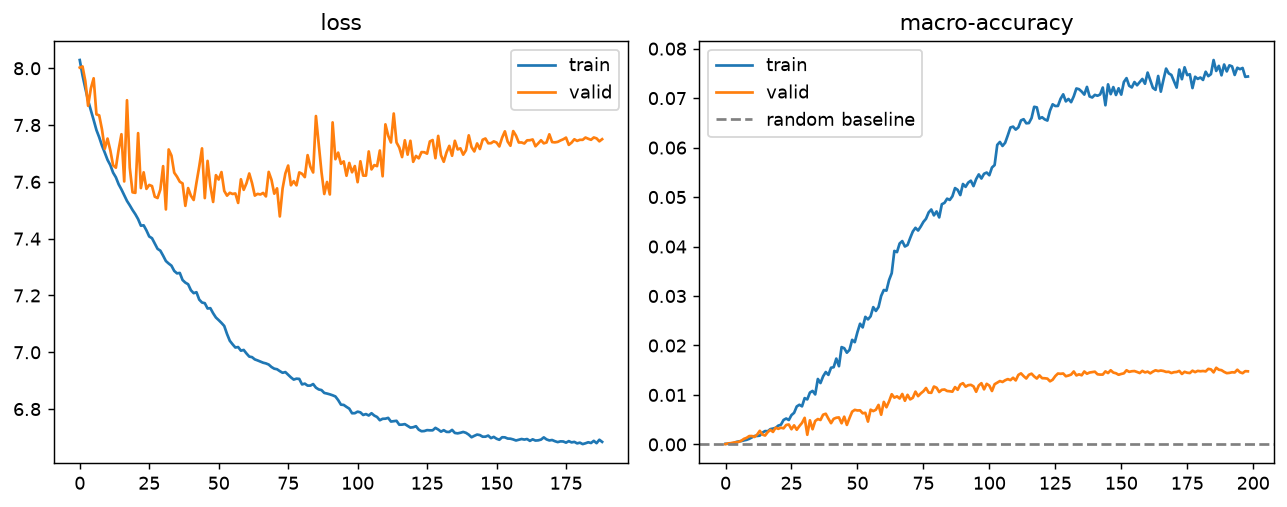

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history['train_loss'][10:], label='train')
axes[0].plot(history['valid_loss'][10:], label='valid')
axes[0].set_title('loss')
axes[0].legend()
axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['valid_acc'], label='valid')
axes[1].axhline(1 / n_classes, color='gray', linestyle='--', label='random baseline')
axes[1].set_title('macro-accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

In [13]:
if EVAL_CHECKPOINT != 'last':
    ckpt = best[EVAL_CHECKPOINT]
    net.load_state_dict(ckpt['state'])
    print(f'loaded {EVAL_CHECKPOINT} checkpoint from epoch {ckpt["epoch"] + 1}  value={ckpt["value"]:.4f}')
else:
    print('using last-epoch weights')

loaded valid_loss checkpoint from epoch 83  value=7.4783


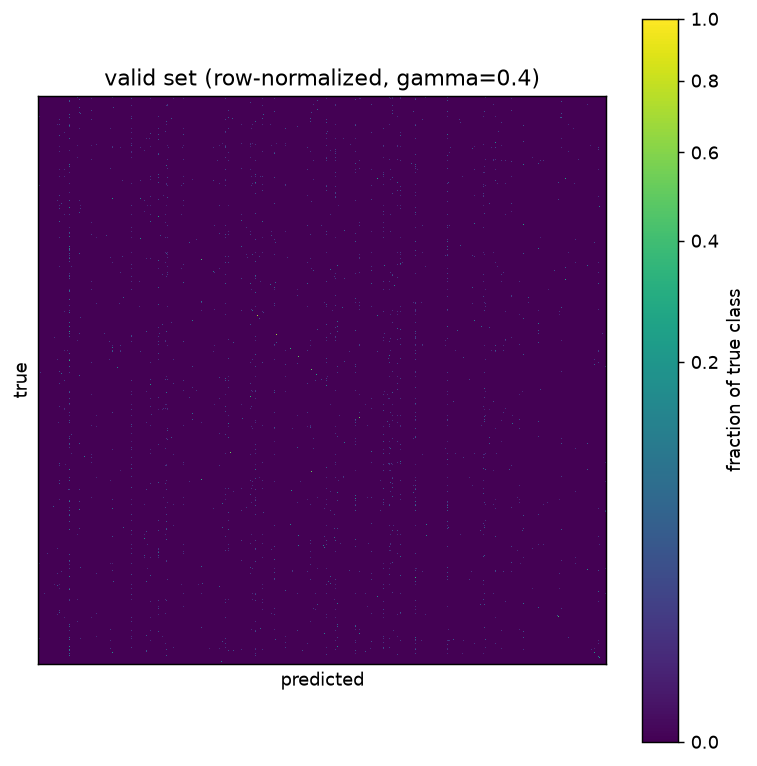

In [14]:
valid_preds, valid_true = train_module.predict(net, valid_loader, DEVICE)
cm_valid = confusion_matrix(valid_true, valid_preds, labels=range(n_classes))
row_sums = cm_valid.sum(axis=1, keepdims=True)
cm_valid_norm = np.divide(cm_valid, row_sums, out=np.zeros_like(cm_valid, dtype=float), where=row_sums != 0)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm_valid_norm, cmap='viridis', norm=mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=1), interpolation='nearest')
if n_classes <= 40:
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels(tickers_sorted, rotation=90)
    ax.set_yticks(range(n_classes))
    ax.set_yticklabels(tickers_sorted)
else:
    ax.set_xticks([])
    ax.set_yticks([])
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('valid set (row-normalized, gamma=0.4)')
plt.colorbar(im, label='fraction of true class')
plt.tight_layout()
plt.show()

In [15]:
cm_valid_offdiag = cm_valid.copy()
np.fill_diagonal(cm_valid_offdiag, 0)
i_idx, j_idx = np.nonzero(cm_valid_offdiag)
counts = cm_valid_offdiag[i_idx, j_idx]
order = np.argsort(-counts)[:15]
valid_pairs = [(tickers_sorted[i], tickers_sorted[j], int(c)) for i, j, c in zip(i_idx[order], j_idx[order], counts[order])]
valid_pairs

[('TM', 'HSBC', 52),
 ('DIS', 'BLLN', 44),
 ('PPG', 'AKRE', 37),
 ('HMC', 'HSBC', 36),
 ('HPQ', 'BLLN', 36),
 ('KO', 'BLLN', 36),
 ('KB', 'HSBC', 36),
 ('DB', 'HSBC', 34),
 ('IBM', 'BLLN', 34),
 ('TT', 'AKRE', 33),
 ('BA', 'BLLN', 32),
 ('IEX', 'AKRE', 32),
 ('BCS', 'HSBC', 32),
 ('ING', 'HSBC', 32),
 ('AME', 'AKRE', 31)]

test accuracy=0.004  macro-accuracy=0.004


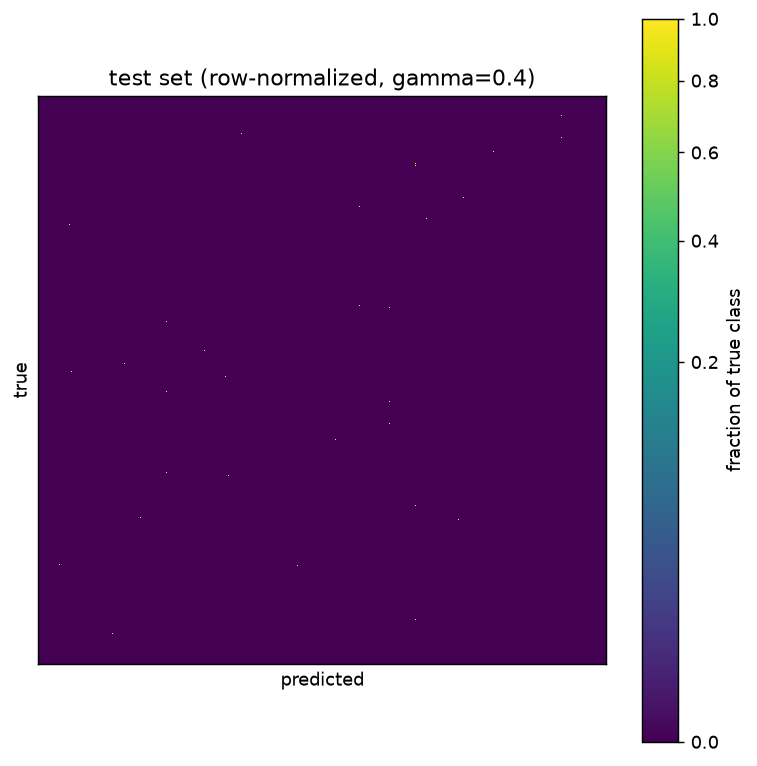

In [16]:
preds, y_true = train_module.predict(net, test_loader, DEVICE)
test_acc = (preds == y_true).mean()
test_macro_acc = train_module.macro_accuracy(torch.tensor(preds), torch.tensor(y_true), n_classes)
print(f'test accuracy={test_acc:.3f}  macro-accuracy={test_macro_acc:.3f}')
cm = confusion_matrix(y_true, preds, labels=range(n_classes))
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm_norm, cmap='viridis', norm=mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=1), interpolation='nearest')
if n_classes <= 40:
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels(tickers_sorted, rotation=90)
    ax.set_yticks(range(n_classes))
    ax.set_yticklabels(tickers_sorted)
else:
    ax.set_xticks([])
    ax.set_yticks([])
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('test set (row-normalized, gamma=0.4)')
plt.colorbar(im, label='fraction of true class')
plt.tight_layout()
plt.show()

In [17]:
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
i_idx, j_idx = np.nonzero(cm_offdiag)
counts = cm_offdiag[i_idx, j_idx]
order = np.argsort(-counts)[:150]
pairs = [(tickers_sorted[i], tickers_sorted[j], int(c)) for i, j, c in zip(i_idx[order], j_idx[order], counts[order])]
pairs

[('A', 'LW', 1),
 ('AA', 'COIN', 1),
 ('AACG', 'ZTG', 1),
 ('AAEQ', 'XOEX', 1),
 ('AAL', 'RGTZ', 1),
 ('AAME', 'GIPR', 1),
 ('AAMI', 'CRGY', 1),
 ('AAOI', 'FRMI', 1),
 ('AAON', 'PINS', 1),
 ('AAP', 'BROS', 1),
 ('AAPG', 'MMSD', 1),
 ('AAPL', 'SFD', 1),
 ('AAPW', 'RVLV', 1),
 ('AARD', 'STRZ', 1),
 ('AAT', 'LGN', 1),
 ('AAUC', 'PARK', 1),
 ('AB', 'AEBI', 1),
 ('ABAT', 'SEV', 1),
 ('ABBV', 'GEV', 1),
 ('ABCB', 'ONTO', 1),
 ('ABCL', 'EXK', 1),
 ('ABEO', 'SOBO', 1),
 ('ABEV', 'VEXC', 1),
 ('ABFL', 'CGNG', 1),
 ('ABG', 'SFD', 1),
 ('ABLD', 'WAMA', 1),
 ('ABLG', 'ZCBC', 1),
 ('ABLS', 'ZHOG', 1),
 ('ABLV', 'BCHT', 1),
 ('ABM', 'NXT', 1),
 ('ABNB', 'HTFL', 1),
 ('ABNG', 'PCG-PC', 1),
 ('ABNY', 'DLXY', 1),
 ('ABOS', 'BLLN', 1),
 ('ABOT', 'HBTC', 1),
 ('ABR', 'DNUT', 1),
 ('ABR-PD', 'YSXT', 1),
 ('ABR-PE', 'INTS', 1),
 ('ABR-PF', 'RTACW', 1),
 ('ABSI', 'ARM', 1),
 ('ABT', 'LGN', 1),
 ('ABTC', 'RGTU', 1),
 ('ABTS', 'TDIC', 1),
 ('ABUS', 'ALMU', 1),
 ('ABVC', 'ALMU', 1),
 ('ABVE', 'JAGU', 1),
 ('AB

In [18]:
def worst_predicted(cm_offdiag, top=20):
    fp_counts = cm_offdiag.sum(axis=0)  # column sums: how often each ticker is wrongly predicted
    n_sources = (cm_offdiag > 0).sum(axis=0)  # distinct true tickers wrongly predicted as this one
    order = np.argsort(-fp_counts)[:top]
    return order, fp_counts, n_sources


for name, offdiag in [('valid', cm_valid_offdiag), ('test', cm_offdiag)]:
    order, fp_counts, n_sources = worst_predicted(offdiag)
    print(f'{name}:')
    for idx in order:
        pct_sources = n_sources[idx] / n_classes * 100
        print(
            f'  {tickers_sorted[idx]:>8}  wrongly predicted {int(fp_counts[idx])} times, '
            f'from {int(n_sources[idx])} different tickers ({pct_sources:.1f}% of all tickers)'
        )
    print()

valid:
      AKRE  wrongly predicted 15905 times, from 2436 different tickers (33.0% of all tickers)
       WBI  wrongly predicted 6773 times, from 2244 different tickers (30.4% of all tickers)
      BLLN  wrongly predicted 6634 times, from 2316 different tickers (31.4% of all tickers)
       ARX  wrongly predicted 6461 times, from 2130 different tickers (28.8% of all tickers)
       MWH  wrongly predicted 5981 times, from 2071 different tickers (28.0% of all tickers)
        SI  wrongly predicted 5854 times, from 1948 different tickers (26.4% of all tickers)
     GLIBK  wrongly predicted 5122 times, from 1890 different tickers (25.6% of all tickers)
       GEV  wrongly predicted 5000 times, from 1648 different tickers (22.3% of all tickers)
      WLTH  wrongly predicted 4780 times, from 1936 different tickers (26.2% of all tickers)
      IYRI  wrongly predicted 4272 times, from 1304 different tickers (17.7% of all tickers)
     LLYVK  wrongly predicted 3788 times, from 1565 different 